# REGRESIÓN LOGISTICA PARA TELCO CUSTOMER CHURN
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df_data = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_3\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
import re

# Función para convertir nombres de columnas a snake_case
def to_snake_case(name):
    name = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1_\2', name)  # Separar mayúsculas juntas
    name = re.sub(r'([a-z\d])([A-Z])', r'\1_\2', name)  # Separar camelCase
    name = name.replace(" ", "_")  # Reemplazar espacios por guiones bajos
    return name.lower()

df_data.columns = [to_snake_case(col) for col in df_data]
df_data

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# EDA

In [37]:
df_data.dtypes.value_counts()

object     18
int64       2
float64     1
dtype: int64

In [38]:
df_data.isna().sum().sum()

0

In [39]:
df_data.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [40]:
df_data.drop('customer_id',axis=1,inplace=True)
df_data.head(2)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [41]:
#Transforma la columna en 1 o 0
df_data['churn'] = df_data['churn'].map({'Yes': 1, 'No': 0})
df_data.head(2)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0


In [42]:
df_data.dtypes

gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges         object
churn                  int64
dtype: object

In [43]:
df_data['total_charges'] = pd.to_numeric(df_data['total_charges'],errors='coerce')
df_data.dtypes

gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                  int64
dtype: object

# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [44]:
df = df_data.copy()
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method'],
      dtype='object')

In [45]:
#Variables categóricas  yes (1) or not (0) 
df['partner'] = df['partner'].map({'Yes': 1, 'No': 0})
df['dependents'] = df['dependents'].map({'Yes': 1, 'No': 0})
df['phone_service'] = df['phone_service'].map({'Yes': 1, 'No': 0})
df['paperless_billing'] = df['paperless_billing'].map({'Yes': 1, 'No': 0})

In [46]:
df.dtypes

gender                object
senior_citizen         int64
partner                int64
dependents             int64
tenure                 int64
phone_service          int64
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing      int64
payment_method        object
monthly_charges      float64
total_charges        float64
churn                  int64
dtype: object

In [47]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Male      3555
Female    3488
Name: gender, dtype: int64
**************************************************
0    3641
1    3402
Name: partner, dtype: int64
**************************************************
0    4933
1    2110
Name: dependents, dtype: int64
**************************************************
1    6361
0     682
Name: phone_service, dtype: int64
**************************************************
No                  3390
Yes                 2971
No phone service     682
Name: multiple_lines, dtype: int64
**************************************************
Fiber optic    3096
DSL            2421
No             1526
Name: internet_service, dtype: int64
**************************************************
No                     3498
Yes                    2019
No internet service    1526
Name: online_security, dtype: int64
**************************************************
No                     3088
Yes                    2429

In [48]:
import sklearn.compose
import sklearn.preprocessing
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OneHotEncoder(),categorical_columns),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(),
                                 Index(['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method'],
      dtype='object'))])

In [49]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)

data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)
data_transformed_df.columns = [to_snake_case(col) for col in data_transformed_df]
data_transformed_df
data_transformed_df

,gender_female,gender_male,partner_0,partner_1,dependents_0,dependents_1,phone_service_0,phone_service_1,multiple_lines_no,multiple_lines_no_phone_service,...,paperless_billing_1,payment_method_bank_transfer_(automatic),payment_method_credit_card_(automatic),payment_method_electronic_check,payment_method_mailed_check,senior_citizen,tenure,monthly_charges,total_charges,churn
0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,29.85,29.85,0.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,34.0,56.95,1889.50,0.0
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,2.0,53.85,108.15,1.0
3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,45.0,42.30,1840.75,0.0
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,24.0,84.80,1990.50,0.0
7039,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,72.0,103.20,7362.90,0.0
7040,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,11.0,29.60,346.45,0.0
7041,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,4.0,74.40,306.60,1.0


In [50]:
corr_matrix = data_transformed_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

churn                                       1.000000
contract_month-to-month                     0.405103
online_security_no                          0.342637
tech_support_no                             0.337281
internet_service_fiber_optic                0.308020
payment_method_electronic_check             0.301919
online_backup_no                            0.268005
device_protection_no                        0.252481
monthly_charges                             0.193356
paperless_billing_1                         0.191825
dependents_0                                0.164221
senior_citizen                              0.150889
partner_0                                   0.150448
streaming_movies_no                         0.130845
streaming_tv_no                             0.128916
streaming_tv_yes                            0.063228
streaming_movies_yes                        0.061382
multiple_lines_yes                          0.040102
phone_service_1                             0.

<Axes: >

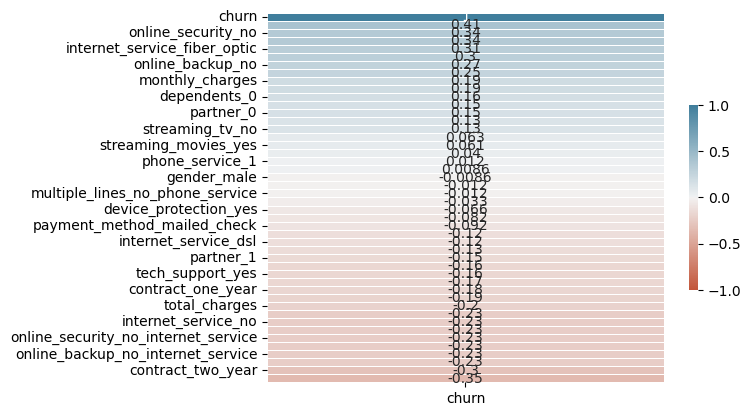

In [51]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [52]:
#Filtro para correlación mayor a 
corr_filtered = corr_churn[corr_churn > 0.3]
cols = corr_filtered.index.tolist()
cols

['internet_service_fiber_optic',
 'online_security_no',
 'tech_support_no',
 'contract_month-to-month',
 'payment_method_electronic_check',
 'churn']

# Entrenando modelo de regresión logística

In [53]:
df_data_processing = data_transformed_df[cols].copy()
df_data_processing.head(5)

,internet_service_fiber_optic,online_security_no,tech_support_no,contract_month-to-month,payment_method_electronic_check,churn
0,0.0,1.0,1.0,1.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0


### Transformación de datos a scalar

In [54]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_data_preprocessing_scaled = scaler.fit_transform(df_data_processing)
df_data_preprocessing_scaled = pd.DataFrame(df_data_preprocessing_scaled)
df_data_preprocessing_scaled.columns = df_data_processing.columns
df_data_preprocessing_scaled

,internet_service_fiber_optic,online_security_no,tech_support_no,contract_month-to-month,payment_method_electronic_check,churn
0,0.0,1.0,1.0,1.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,0.0,0.0
7039,1.0,1.0,1.0,0.0,0.0,0.0
7040,0.0,0.0,1.0,1.0,1.0,0.0
7041,1.0,1.0,1.0,1.0,0.0,1.0


In [55]:
#Diferenciar variables dependientes de variables independientes
X = df_data_preprocessing_scaled.drop('churn',axis=1)
y = df_data_preprocessing_scaled['churn'].values

In [56]:
# Tomamos variables de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [57]:
#Aplicando modelo Logístico
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
result = model.fit(X_train,y_train)

In [58]:
# Metricas del modelo
from sklearn import metrics
y_pred = model.predict(X_test)
print(f'accuracy : {metrics.accuracy_score(y_test,y_pred)}')

accuracy : 0.7841930903928065


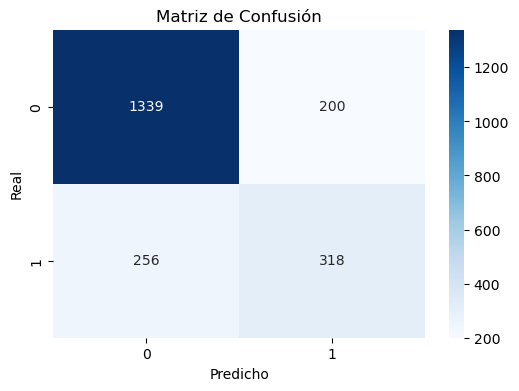

In [59]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [60]:
# Reporte de clasificación
class_report = classification_report(y_test, y_pred)
# Mostrar resultados
print(f"Precisión del modelo: {accuracy:.4f}")
print("\nMatriz de Confusión:")
print(conf_matrix)
print("\nReporte de Clasificación:")
print(class_report)

Precisión del modelo: 0.8800

Matriz de Confusión:
[[1339  200]
 [ 256  318]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85      1539
         1.0       0.61      0.55      0.58       574

    accuracy                           0.78      2113
   macro avg       0.73      0.71      0.72      2113
weighted avg       0.78      0.78      0.78      2113



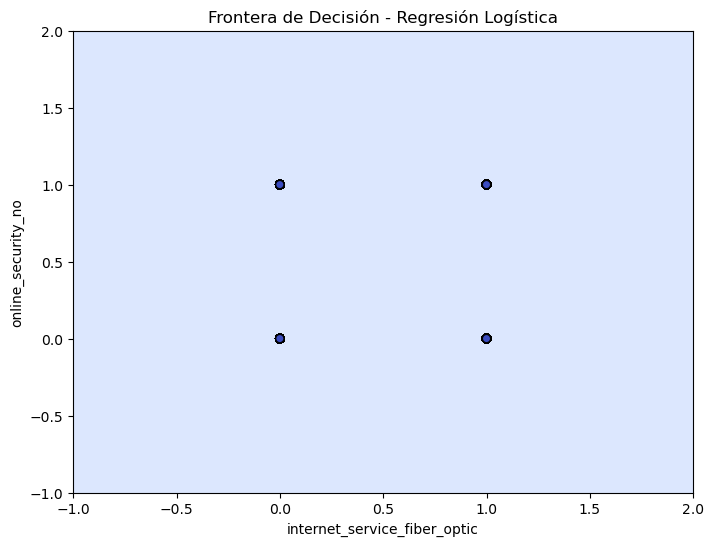

In [68]:
# Graficar datos de prueba y la frontera de decisión
plt.figure(figsize=(8,6))

# Get the feature names used during training
feature_names = X_train.columns 

# Select the first two features for visualization
# Adjust the column indices (0 and 1) if you want to visualize different features
x_min, x_max = X_test[feature_names[0]].min() - 1, X_test[feature_names[0]].max() + 1  
y_min, y_max = X_test[feature_names[2]].min() - 1, X_test[feature_names[2]].max() + 1  

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Create a DataFrame for prediction using the meshgrid values and feature names
# This ensures the input data has the same structure as the training data
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[feature_names[0], feature_names[1]])

# Impute missing columns with 0 to match the number of features in training data
for col in feature_names:
    if col not in grid_df.columns:
        grid_df[col] = 0 

# Ensure the columns are in the same order as during training
grid_df = grid_df[feature_names]

# Predecir en la malla de valores using the grid_df
Z = model.predict(grid_df)  
Z = Z.reshape(xx.shape)

# Dibujar la frontera de decisión
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Graficar los puntos de datos
# Use the feature names to access columns for the scatter plot
plt.scatter(X_test[feature_names[0]], X_test[feature_names[1]], c=y_test, edgecolor='k', cmap="coolwarm")  

# Etiquetas
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Frontera de Decisión - Regresión Logística")
plt.show()